# Revised GFDL-ESM4 sampling-sensitivity figure

Consistent reconstruction colors, separate legends, no random-global series, and linear 1×–4×–8× spacing.

# GFDL-ESM4 sampling sensitivity: trend-error maps and volume-weighted MAE

Panels **a-b** show the control-sampling, sampled-and-mapped minus fully sampled Ito (2024) random-forest (RF) oxygen-trend error for the upper 2000 m and below 2000 m. Panel **a** overlays the artificial profile experiments.

Panels **c-d** compare Ito (2024) RF and Ito (2022) using grouped bars for six control and artificial-profile sampling experiments. All MAEs use the tropical Pacific + Indian domain so Original can be compared directly with the 4x and 8x experiments. Missing method-experiment products are left blank.


In [1]:
from pathlib import Path

import netCDF4 as nc
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.colors import TwoSlopeNorm
from cartopy import crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

PAPER = Path('/scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures')
ARTIFICIAL = Path('/scratch/gpfs/LRGROUP/db9274/GFDL_ESM4_artificial_subsampling')
TREND_DIR = ARTIFICIAL / 'trend_comparison_outputs/fully_minus_gap_filled_trend_maps'
UNIFORM_CACHE = TREND_DIR / 'fully_minus_gap_filled_level_first_volume_weighted_1965_2021.nc'
SHIP_CACHE = TREND_DIR / 'ito2024_nn_original_4x_4xeast_8x.nc'
OI_UNIFORM_CACHE = TREND_DIR / 'ito2022_fully_minus_gap_filled_level_first_volume_weighted_1967_2019.nc'
OI_SHIP_CACHE = TREND_DIR / 'ito2022_original_4x_4xeast_8x.nc'
RF_SHIP_CACHE = TREND_DIR / 'ito2024_rf_original_4x_4xeast_8x.nc'
RF_05_CACHE = TREND_DIR / 'fully_minus_gap_filled_rf_pct05_level_first_volume_weighted_1965_2021.nc'
BASIN_MASK = Path('/scratch/gpfs/GEOCLIM/LRGROUP/db9274/Analysis/Variability_quantification/Ito_2022_OI_algorithm/optint_wod_o2/basin_mask_01.nc')
RAND_MASK = ARTIFICIAL / 'annual_masks/annual_mask_GFDL_ESM4_r1i1p1f1_randobs.nc'
RAND_NN = ARTIFICIAL / 'workflows/Ito_2024_NN/NETCDF/Artificial_subsampling_NN/GFDL_ESM4_randobs_r1i1p1f1_oxygen_gridded_NN.nc'
RAND_RF = ARTIFICIAL / 'workflows/Ito_2024_NN/NETCDF/Artificial_subsampling_RF/GFDL_ESM4_randobs_r1i1p1f1_oxygen_gridded_RF.nc'
RAND_OI = ARTIFICIAL / 'workflows/Ito_2022_OI/NETCDF/processed/o2_grid_1x1_GFDL_ESM4_randobs.nc'
RAND_TREND_CACHE = PAPER / 'cache_gfdl_esm4_randobs_trend_error_maps.nc'
FULL = PAPER / 'NETCDF/Fully_sampled_models_annual_o2/o2_1x1bin_GFDL_ESM4_r1i1p1f1.nc'

MASKS = {
    '4x': ARTIFICIAL / 'annual_masks/annual_added_shiptrack_mask_GFDL_ESM4_r1i1p1f1_ship4x.nc',
    '4x east-Pacific': ARTIFICIAL / 'annual_masks/annual_added_shiptrack_mask_GFDL_ESM4_r1i1p1f1_ship4x_eastpac.nc',
    '8x': ARTIFICIAL / 'annual_masks/annual_added_shiptrack_mask_GFDL_ESM4_r1i1p1f1_ship8x.nc',
}
UNIFORM_MASKS = {
    key: ARTIFICIAL / f'annual_masks/annual_mask_GFDL_ESM4_r1i1p1f1_pct{key}.nc'
    for key in ('05', '10', '30', '50', '70')
}
required = [UNIFORM_CACHE, SHIP_CACHE, OI_UNIFORM_CACHE, OI_SHIP_CACHE, RF_SHIP_CACHE, RF_05_CACHE, BASIN_MASK, RAND_MASK, RAND_NN, RAND_RF, FULL, *MASKS.values(), *UNIFORM_MASKS.values()]
missing = [str(path) for path in required if not path.exists()]
assert not missing, 'Missing inputs:\n' + '\n'.join(missing)

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 600, 'font.size': 8,
    'axes.titlesize': 8.5, 'axes.labelsize': 8, 'xtick.labelsize': 8,
    'ytick.labelsize': 8, 'legend.fontsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 0.7, 'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.facecolor': 'white', 'savefig.edgecolor': 'none',
})
BANDS = {'upper_2000m': (0.0, 2000.0), 'below_2000m': (2000.0, None)}
BAND_LABELS = {'upper_2000m': 'Upper 2000 m', 'below_2000m': 'Below 2000 m'}


In [2]:
def layer_edges(lev):
    lev = np.asarray(lev, dtype=float)
    edges = np.empty(lev.size + 1)
    edges[1:-1] = 0.5 * (lev[:-1] + lev[1:])
    edges[0] = max(0.0, lev[0] - 0.5 * (lev[1] - lev[0]))
    edges[-1] = lev[-1] + 0.5 * (lev[-1] - lev[-2])
    return edges

def band_thickness(lev, top, bottom):
    edges = layer_edges(lev)
    bottom = np.inf if bottom is None else float(bottom)
    return np.maximum(np.minimum(edges[1:], bottom) - np.maximum(edges[:-1], top), 0.0)

def grid_area(lat, lon, radius=6_371_000.0):
    lat_edges = np.empty(lat.size + 1)
    lat_edges[1:-1] = 0.5 * (lat[:-1] + lat[1:])
    lat_edges[0], lat_edges[-1] = -90.0, 90.0
    dlon = np.deg2rad(np.median(np.diff(lon)))
    strips = radius**2 * dlon * np.diff(np.sin(np.deg2rad(lat_edges)))
    return np.broadcast_to(strips[:, None], (lat.size, lon.size)).copy()

# Valid-ocean volume per horizontal column for each depth band.
with nc.Dataset(FULL) as ds:
    lev = np.asarray(ds.variables['lev'][:], dtype=float)
    lat = np.asarray(ds.variables['y'][:], dtype=float)
    lon = np.mod(np.asarray(ds.variables['x'][:], dtype=float), 360)
    o2 = ds.variables['o2']
    time_axis = o2.dimensions.index('time')
    index = [slice(None)] * o2.ndim
    index[time_axis] = 0
    snapshot = np.ma.filled(o2[tuple(index)], np.nan)
    remaining = [dim for dim in o2.dimensions if dim != 'time']
    snapshot = np.transpose(snapshot, [remaining.index('lev'), remaining.index('y'), remaining.index('x')])

area = grid_area(lat, lon)
column_volume = {}
for band, (top, bottom) in BANDS.items():
    dz = band_thickness(lev, top, bottom)[:, None, None]
    valid = np.isfinite(snapshot) & (dz > 0)
    column_volume[band] = np.sum(np.where(valid, dz * area[None, :, :], 0.0), axis=0)

# Six-basin surface mask: Pacific=2 and Indian=3. Restrict each to the
# tropical latitude bounds used by the ship-track generation workflow.
with xr.open_dataset(BASIN_MASK) as basin_ds:
    basin = basin_ds.basin_mask.isel(depth=0).load()
basin = basin.assign_coords(lon=np.mod(basin.lon, 360)).sortby('lon')
basin_values = basin.values
lat2d = np.broadcast_to(lat[:, None], basin_values.shape)
tropical_ship_region = (
    ((basin_values == 2) & (lat2d >= -20) & (lat2d <= 20)) |
    ((basin_values == 3) & (lat2d >= -30) & (lat2d <= 30))
)

def volume_weighted_mae(field, band, region=None):
    values = np.asarray(field, dtype=float)
    weights = column_volume[band]
    valid = np.isfinite(values) & (weights > 0)
    if region is not None:
        valid &= region
    return np.average(np.abs(values[valid]), weights=weights[valid])


def read_years(ds):
    return np.array([d.year for d in nc.num2date(
        ds.variables['time'][:], ds.variables['time'].units,
        calendar=getattr(ds.variables['time'], 'calendar', 'standard'))], dtype=int)

def calculate_level_trends(path, start, end):
    wanted = np.arange(start, end + 1)
    with nc.Dataset(path) as ds:
        years = read_years(ds)
        zn = 'lev' if 'lev' in ds.variables else 'depth'
        yn = 'y' if 'y' in ds.variables else 'lat'
        xn = 'x' if 'x' in ds.variables else 'lon'
        z=np.asarray(ds.variables[zn][:],float); yy=np.asarray(ds.variables[yn][:],float)
        xx=np.mod(np.asarray(ds.variables[xn][:],float),360)
        v=ds.variables['o2']; ta=v.dimensions.index('time')
        rem=[d for d in v.dimensions if d!='time']; order=[rem.index(d) for d in (zn,yn,xn)]
        shape=(z.size,yy.size,xx.size)
        a={k:np.zeros(shape,float) for k in ('n','sx','sy','sxx','sxy')}
        for year in wanted:
            total=np.zeros(shape,float); count=np.zeros(shape,np.uint8)
            for ti in np.flatnonzero(years==year):
                idx=[slice(None)]*v.ndim; idx[ta]=int(ti)
                x=np.ma.filled(v[tuple(idx)],np.nan).astype(float); x[x>1e19]=np.nan
                x=np.transpose(x,order); good=np.isfinite(x)
                total+=np.where(good,x,0); count+=good
            annual=np.divide(total,count,out=np.full(shape,np.nan),where=count>0)
            good=np.isfinite(annual)
            a['n']+=good; a['sx']+=np.where(good,year,0); a['sy']+=np.where(good,annual,0)
            a['sxx']+=np.where(good,year*year,0); a['sxy']+=np.where(good,year*annual,0)
        den=a['n']*a['sxx']-a['sx']**2
        trend=np.divide(a['n']*a['sxy']-a['sx']*a['sy'],den,out=np.full(shape,np.nan),
                        where=(a['n']==wanted.size)&(den!=0))*10
    return z,yy,xx,trend

def difference_maps(full_trend, mapped_trend, z):
    diff=full_trend-mapped_trend; result={}
    for band,(top,bottom) in BANDS.items():
        dz=band_thickness(z,top,bottom)[:,None,None]
        valid=np.isfinite(diff)&(dz>0)
        den=np.sum(np.where(valid,dz,0),axis=0)
        num=np.nansum(np.where(valid,diff*dz,np.nan),axis=0)
        result[band]=np.divide(num,den,out=np.full_like(num,np.nan),where=den>0)
    return result

if RAND_TREND_CACHE.exists():
    rand_trends=xr.open_dataset(RAND_TREND_CACHE).load()
else:
    rand_trends=xr.Dataset(coords={'lat':lat,'lon':lon})
random_products={'rf':(RAND_RF,1965,2021)}
if RAND_OI.exists():
    random_products['oi']=(RAND_OI,1967,2019)
changed=False; full_trends={}
for method,(path,start,end) in random_products.items():
    if all(f'randobs_{method}_{band}' in rand_trends for band in BANDS):
        continue
    if (start,end) not in full_trends:
        full_trends[start,end]=calculate_level_trends(FULL,start,end)
    z0,y0,x0,ft=full_trends[start,end]
    z1,y1,x1,mt=calculate_level_trends(path,start,end)
    if not (np.allclose(z0,z1) and np.allclose(y0,y1) and np.allclose(x0,x1)):
        raise ValueError(f'Coordinate mismatch for {path}')
    for band,values in difference_maps(ft,mt,z0).items():
        rand_trends[f'randobs_{method}_{band}']=(('lat','lon'),values.astype('float32'))
    changed=True
if changed:
    tmp=RAND_TREND_CACHE.with_suffix('.nc.tmp')
    rand_trends.to_netcdf(tmp,encoding={v:{'zlib':True,'complevel':4} for v in rand_trends.data_vars})
    tmp.replace(RAND_TREND_CACHE)

oi_uniform = xr.open_dataset(OI_UNIFORM_CACHE)
oi_ship = xr.open_dataset(OI_SHIP_CACHE)
rf_ship = xr.open_dataset(RF_SHIP_CACHE)
rf05 = xr.open_dataset(RF_05_CACHE)

with xr.open_dataset(RAND_MASK) as random_mask:
    random_pct = {
        'upper_2000m': float(random_mask.achieved_upper_0_2000_fraction.mean()) * 100,
        'below_2000m': float(random_mask.achieved_below_2000_fraction.mean()) * 100,
    }
original_pct = random_pct.copy()
uniform_percent = {}
for band in BANDS:
    uniform_percent[band] = {}
    for key, path in UNIFORM_MASKS.items():
        with xr.open_dataset(path) as mask:
            name = 'upper_0_2000_fraction' if band == 'upper_2000m' else 'below_2000_fraction'
            uniform_percent[band][key] = float(mask[name].mean()) * 100

rows = []
uniform_sources = {'Ito (2022) OI': oi_uniform}
for method, dataset in uniform_sources.items():
    for band in BANDS:
        rows.append({'family': 'uniform', 'method': method, 'band': band, 'case': 'Original',
                     'observed_percent': original_pct[band],
                     'mae': volume_weighted_mae(dataset[f'fully_minus_gap_filled_original_{band}'], band, region=tropical_ship_region)})
        for key in UNIFORM_MASKS:
            rows.append({'family': 'uniform', 'method': method, 'band': band, 'case': f'{int(key)}%',
                         'observed_percent': uniform_percent[band][key],
                         'mae': volume_weighted_mae(dataset[f'fully_minus_gap_filled_{key}_{band}'], band, region=tropical_ship_region)})

# Random-global sampling has the same observed volume as original sampling.
for method, key in [('Ito (2022) OI', 'oi'), ('Ito (2024) RF', 'rf')]:
    for band in BANDS:
        name = f'randobs_{key}_{band}'
        if name in rand_trends:
            rows.append({'family':'uniform','method':method,'band':band,'case':'Random global',
                         'observed_percent':random_pct[band],
                         'mae':volume_weighted_mae(rand_trends[name],band,region=tropical_ship_region)})

# Only original and 5% uniform RF products currently exist.
for band in BANDS:
    rows.extend([
        {'family': 'uniform', 'method': 'Ito (2024) RF', 'band': band, 'case': 'Original',
         'observed_percent': original_pct[band],
         'mae': volume_weighted_mae(rf_ship[f'fully_minus_gap_filled_original_{band}'], band, region=tropical_ship_region)},
        {'family': 'uniform', 'method': 'Ito (2024) RF', 'band': band, 'case': '5%',
         'observed_percent': uniform_percent[band]['05'],
         'mae': volume_weighted_mae(rf05[f'fully_minus_gap_filled_rf05_{band}'], band)},
    ])

ship_sources = {'Ito (2022) OI': oi_ship, 'Ito (2024) RF': rf_ship}
for method, dataset in ship_sources.items():
    for band in BANDS:
        for key, label in [('original', 'Original'), ('ship4x', '4x'),
                           ('ship4x_eastpac', '4x east-Pacific'), ('ship8x', '8x')]:
            rows.append({
                'family': 'ship tracks', 'method': method, 'band': band, 'case': label,
                'observed_percent': np.nan,
                'mae': volume_weighted_mae(
                    dataset[f'fully_minus_gap_filled_{key}_{band}'], band,
                    region=tropical_ship_region,
                ),
            })

metrics = pd.DataFrame(rows)
METRICS_CSV = PAPER / 'gfdl_esm4_sampling_sensitivity_volume_weighted_mae.csv'
metrics.to_csv(METRICS_CSV, index=False)
metrics


,family,method,band,case,observed_percent,mae
0,uniform,Ito (2022) OI,upper_2000m,Original,4.438417,0.274857
1,uniform,Ito (2022) OI,upper_2000m,5%,5.000047,0.137811
2,uniform,Ito (2022) OI,upper_2000m,10%,10.000031,0.133875
3,uniform,Ito (2022) OI,upper_2000m,30%,30.000037,0.128782
4,uniform,Ito (2022) OI,upper_2000m,50%,50.000050,0.127919
5,uniform,Ito (2022) OI,upper_2000m,70%,70.000041,0.127977
6,uniform,Ito (2022) OI,below_2000m,Original,1.390341,0.314570
7,uniform,Ito (2022) OI,below_2000m,5%,5.000076,0.067589
8,uniform,Ito (2022) OI,below_2000m,10%,10.000084,0.064280
9,uniform,Ito (2022) OI,below_2000m,30%,30.000091,0.060692


In [3]:
# Track footprints shown as horizontal cells occupied in any year at any depth.
track_masks = {}
for label, path in MASKS.items():
    with xr.open_dataset(path) as ds:
        track_masks[label] = ds.added_sample_mask.any(('year', 'lev')).load()

# Because 8x is nested around 4x, show only its additional cells.
track_masks['8x additions'] = track_masks['8x'] & ~track_masks['4x']

def track_points(mask, phase=0, spacing=4):
    yy, xx = np.where(mask.values)
    keep = ((yy + xx) % spacing) == phase
    return mask.x.values[xx[keep]], mask.y.values[yy[keep]]

track_style = {
    '4x': dict(color='#7b3294', marker='s', s=8, alpha=0.90, label='4x'),
    '4x east-Pacific': dict(color='#0086a8', marker='o', s=8, alpha=0.90, label='4x east-Pacific'),
    '8x additions': dict(color='#e66101', marker='^', s=12, alpha=1.0, label='8x additions'),
}

# Mean number of added full-depth profile locations per year. Each ship-track
# mask adds the complete local water column at an occupied horizontal cell.
additional_profiles = {}
for label, path in MASKS.items():
    with xr.open_dataset(path) as ds:
        yearly_profiles = ds.added_sample_mask.any('lev').sum(('y', 'x'))
        additional_profiles[label] = int(np.rint(yearly_profiles.mean().item()))


/tmp/ipykernel_651853/1899739583.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved Figures/GFDL_ESM4_sampling_sensitivity_six_panel.pdf


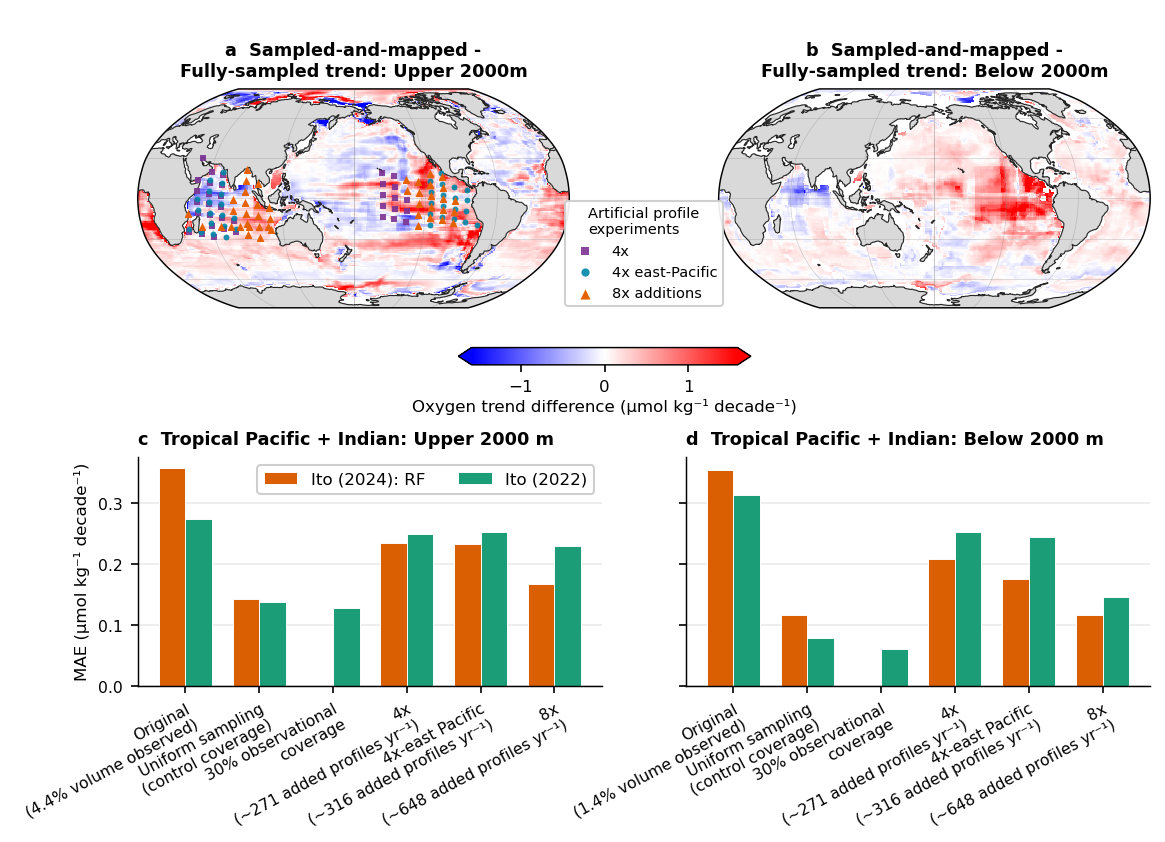

In [4]:
fig = plt.figure(figsize=(7.5, 6.4))
gs = fig.add_gridspec(2, 1, height_ratios=(1.25, 0.78), left=0.085, right=0.985,
                      bottom=0.25, top=0.95, hspace=0.25)
projection = ccrs.Robinson(central_longitude=180)
top_gs = gs[0].subgridspec(1, 3, width_ratios=(1, 0.30, 1), wspace=0.03)
map_axes = [fig.add_subplot(top_gs[0, 0], projection=projection),
            fig.add_subplot(top_gs[0, 2], projection=projection)]
legend_ax = fig.add_subplot(top_gs[0, 1])
legend_ax.axis('off')
cbar_ax = fig.add_axes([0.37, 0.585, 0.26, 0.018])
cbar_ax.set_in_layout(False)
bottom_gs = gs[1].subgridspec(1, 2, wspace=0.18)
bottom_axes = [fig.add_subplot(bottom_gs[0, i]) for i in range(2)]

map_fields = [-rf_ship.fully_minus_gap_filled_original_upper_2000m,
              -rf_ship.fully_minus_gap_filled_original_below_2000m]
limit = float(np.nanpercentile(np.concatenate([np.abs(x.values).ravel() for x in map_fields]), 99))
norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
for ax, field, band, panel in zip(map_axes, map_fields, BANDS, ('a', 'b')):
    cyclic, cyclic_lon = add_cyclic_point(field.values, coord=field.lon.values)
    mesh = ax.pcolormesh(cyclic_lon, field.lat, cyclic, transform=ccrs.PlateCarree(),
                         cmap='bwr', norm=norm, shading='auto', rasterized=True)
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor='0.85', edgecolor='none', zorder=2)
    ax.coastlines(linewidth=0.55, color='0.15', zorder=3)
    ax.gridlines(linewidth=0.3, color='0.55', alpha=0.45)
    depth_label = 'Upper 2000m' if band == 'upper_2000m' else 'Below 2000m'
    ax.set_title(f'{panel}  Sampled-and-mapped -\nFully-sampled trend: {depth_label}',
                 loc='center', fontweight='bold', fontsize=8.5)
for name in ('4x', '4x east-Pacific', '8x additions'):
    phase, spacing, zorder = {'4x': (0, 8, 4), '4x east-Pacific': (2, 8, 5),
                              '8x additions': (0, 8, 7)}[name]
    xmap, ymap = track_points(track_masks[name], phase=phase, spacing=spacing)
    map_axes[0].scatter(xmap, ymap, transform=ccrs.PlateCarree(), linewidths=0,
                        zorder=zorder, **track_style[name])
handles, labels = map_axes[0].get_legend_handles_labels()
legend_ax.legend(handles, labels, loc='center', bbox_to_anchor=(0.5, 0.35),
                 frameon=True, framealpha=0.92, fontsize=7, markerscale=1.4,
                 title='Artificial profile\nexperiments', title_fontsize=7)
cbar = fig.colorbar(mesh, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label('Oxygen trend difference (\u00b5mol kg\u207b\u00b9 decade\u207b\u00b9)')

method_styles = {
    'Ito (2024) RF': dict(color='#d95f02', label='Ito (2024): RF'),
    'Ito (2022) OI': dict(color='#1b9e77', label='Ito (2022)'),
}
case_specs = [
    ('Original', 'uniform', 'Original'),
    ('Uniform sampling\n(control coverage)', 'uniform', 'Random global'),
    ('30% observational\ncoverage', 'uniform', '30%'),
    ('4x', 'ship tracks', '4x'),
    ('4x-east Pacific', 'ship tracks', '4x east-Pacific'),
    ('8x', 'ship tracks', '8x'),
]
case_labels = [spec[0] for spec in case_specs]
for i, (label, family, case) in enumerate(case_specs):
    if case in additional_profiles:
        case_labels[i] = f'{label}\n(~{additional_profiles[case]:,} added profiles yr\u207b\u00b9)'
xbar = np.arange(len(case_specs))
width = 0.36
for ax, band, panel in zip(bottom_axes, BANDS, ('c', 'd')):
    panel_case_labels = case_labels.copy()
    panel_case_labels[0] = f'Original\n({original_pct[band]:.1f}% volume observed)'
    for offset, (method, style) in zip((-width / 2, width / 2), method_styles.items()):
        values = []
        for _, family, case in case_specs:
            match = metrics[(metrics.family == family) & (metrics.band == band) &
                            (metrics.method == method) & (metrics.case == case)]
            values.append(float(match.mae.iloc[0]) if len(match) else np.nan)
        ax.bar(xbar + offset, values, width=width, color=style['color'],
               label=style['label'], edgecolor='white', linewidth=0.45)
    ax.set_xticks(xbar, panel_case_labels, rotation=28, ha='right', rotation_mode='anchor')
    ax.set_title(f'{panel}  Tropical Pacific + Indian: {BAND_LABELS[band]}',
                 loc='left', fontweight='bold', fontsize=8.5)
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)
    ax.set_ylim(bottom=0)
    ax.tick_params(axis='both', labelsize=7.5)
bottom_axes[0].set_ylabel('MAE (\u00b5mol kg\u207b\u00b9 decade\u207b\u00b9)')
shared_top = max(ax.get_ylim()[1] for ax in bottom_axes)
for ax in bottom_axes:
    ax.set_ylim(0, shared_top)
bottom_axes[1].tick_params(axis='y', labelleft=False)
bottom_axes[0].legend(loc='upper right', ncol=2, frameon=True, framealpha=0.95)
cbar.ax.tick_params(labelsize=8)
cbar.ax.xaxis.labelpad = 2
cbar.set_label('Oxygen trend difference (\u00b5mol kg\u207b\u00b9 decade\u207b\u00b9)', fontsize=8)

fig.tight_layout()
OUTPUT_DIR = Path('Figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_PDF = OUTPUT_DIR / 'GFDL_ESM4_sampling_sensitivity_six_panel.pdf'
fig.savefig(FIG_PDF, bbox_inches='tight', pad_inches=0.03, facecolor='white')
print(f'Saved {FIG_PDF}')
plt.show()
